In [1]:
# Install if needed
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [7]:
data = pd.read_csv("C:\\Users\\inter\\Desktop\\sanika surve\\Machine learning\\news\\world news in month.csv", encoding='latin1')
print(data.head())

   Unnamed: 0                                               text name  \
0           1  Theresa May has struck a deal with Brussels th...   UK   
1           2  The agreement may give UK firms continued acce...   UK   
2           3  Nobody knows when, but the Brexit secretary, D...   UK   
3           4  There's no shame in asking voters to express t...   UK   
4           5  Dominic Raab warns that "obstacles remain" but...   UK   

         Date  sentiment  
0  2018-11-01          0  
1  2018-11-01          1  
2  2018-11-01          0  
3  2018-11-01          0  
4  2018-11-01          0  


In [8]:
data = pd.DataFrame({
    "text": [
        "Government passes new law in parliament",
        "Stock markets rise as economy improves",
        "New AI technology is transforming industries",
        "Football team wins championship",
        "New smartphone released with advanced features",
        "Election results spark political debate",
        "Scientists discover new species in ocean",
        "Basketball tournament draws huge crowd"
    ]
})

In [9]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['text'])
print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (8, 36)


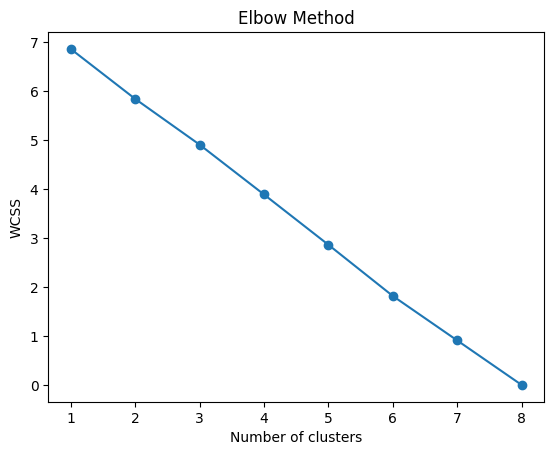

In [11]:
wcss = []

for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 9), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
k = 3  # change based on elbow graph
kmeans = KMeans(n_clusters=k, random_state=42)

data['Cluster'] = kmeans.fit_predict(X)

print(data)

                                             text  Cluster
0         Government passes new law in parliament        2
1          Stock markets rise as economy improves        0
2    New AI technology is transforming industries        0
3                 Football team wins championship        0
4  New smartphone released with advanced features        0
5         Election results spark political debate        0
6        Scientists discover new species in ocean        0
7          Basketball tournament draws huge crowd        1


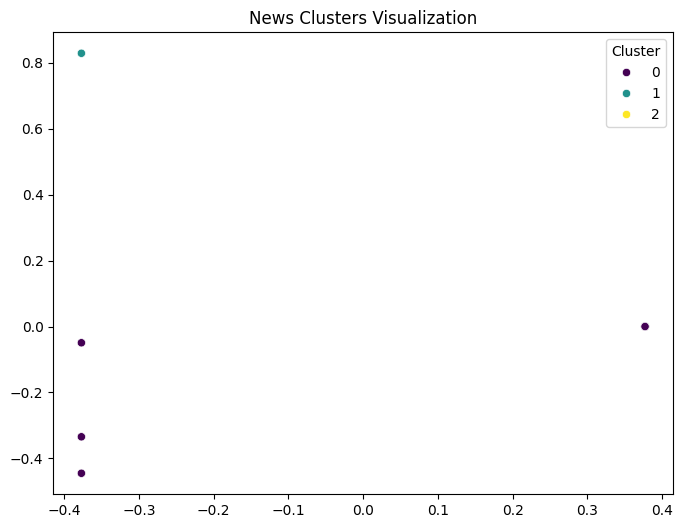

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data['Cluster'], palette='viridis')
plt.title("News Clusters Visualization")
plt.show()

In [14]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    print(f"\nCluster {i} Top Words:")
    center = kmeans.cluster_centers_[i]
    top_words = [terms[ind] for ind in center.argsort()[-10:]]
    print(top_words)


Cluster 0 Top Words:
['ocean', 'released', 'technology', 'transforming', 'industries', 'football', 'championship', 'team', 'wins', 'new']

Cluster 1 Top Words:
['stock', 'team', 'transforming', 'wins', 'technology', 'huge', 'draws', 'crowd', 'basketball', 'tournament']

Cluster 2 Top Words:
['team', 'technology', 'wins', 'transforming', 'tournament', 'new', 'passes', 'law', 'parliament', 'government']
